In [4]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
from itertools import chain
from collections import Counter

# from simulator import Simulation
from tqdm.auto import tqdm
import itertools
import matplotlib as mpl
from collections import OrderedDict, defaultdict

from voting_mechanism_design.agents.pairwise_badgeholder import PairwiseBadgeholder, PairwiseBadgeholderPopulation
from voting_mechanism_design.projects.project import Project, ProjectPopulation
from voting_mechanism_design.funds_distribution.pairwise_binary import PairwiseBinary
from voting_mechanism_design.sim import RoundSimulation

from voting_mechanism_design.agents.quorum_badgeholder import QuorumBadgeholder, QuorumBadgeholderPopulation
from voting_mechanism_design.funds_distribution.threshold_and_aggregate import ThresholdAndAggregate

# # OP simulator configuration
# from voting_mechanism_design.legacy.op_simulator import Simulation as OPSimulation
# from voting_mechanism_design.legacy.op_simulator import Round as OPRound
# from voting_mechanism_design.legacy.op_simulator import Voter as OPVoter
# from voting_mechanism_design.legacy.op_simulator import Project as OPProject

import itertools
import numpy as np
import choix
import math

import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

from tqdm.auto import tqdm
from joblib import Parallel, delayed

warnings.simplefilter(action='ignore', category=UserWarning)
warnings.simplefilter(action="ignore", category=RuntimeWarning)

In [6]:
#Test simulation for incentive_alignment

def run_single_quorum_threshold_incentive_alignment_simulation(
        n_badgeholders=50,
        badgeholder_expertise_vec=None,
        badgeholder_laziness_vec=None,
        n_projects=100,
        project_impact_vec=None,
        # configuration specific to quorum+threshold voting method
        quorum=5,
        scoring_fn='mean',
        min_vote_amt=1,
        max_vote_amt=16,
        max_funding=100,
        random_seed=1234
        #,misalignment_scale=100
    ):
    # create voters
    voters = []
    for ii in range(n_badgeholders):
        assert badgeholder_laziness_vec[ii] >= 0
        v = QuorumBadgeholder(
            badgeholder_id=ii,
            total_funds=max_funding,
            min_vote=min_vote_amt,  
            max_vote=max_vote_amt,
            laziness=badgeholder_laziness_vec[ii],
            expertise=badgeholder_expertise_vec[ii]
            #,expertise_model="k2"
        )
        voters.append(v)
    badgeholder_pop=QuorumBadgeholderPopulation()
    badgeholder_pop.add_badgeholders(voters)

    # add projects
    projects = []
    for ii in range(n_projects):
        p = Project(
            project_id=ii,
            true_impact=project_impact_vec[ii],  
            owner_id=None,  
        )
        projects.append(p)
    project_population = ProjectPopulation()
    project_population.add_projects(projects)

    # ##  Voting Simulation
    fund_distribution_model = ThresholdAndAggregate(
        scoring_method=scoring_fn,
        quorum=quorum,
        min_amount=0
    )
    simulation_obj = RoundSimulation(
        badgeholder_population=badgeholder_pop,
        projects=project_population,
        funding_design=fund_distribution_model,
        random_seed=random_seed
    )
    projects = project_population.get_projects()
    simulation_obj.run()

    projectid2score = simulation_obj.projectid2score

    # for easy comparison
    projectid2score = OrderedDict(projectid2score) #a dictionary mapping project id to score
    ranks = np.argsort(np.asarray(list(projectid2score.values()))) #a list of project id from lowest ranked to highest ranked
    #projectid2rank = {ii:ranks[ii] for ii in range(len(ranks))}

    #INCENTIVE ALIGNMENT MEASUREMENT
    #diff=[] 
    #dictionary: key -- voter, value -- list of dictionaries, CHANGED TO A DICTIONARY -- {voter:{project_id: amount, project_id: amount ...},...}
    diff = {}
    rankList=ranks.tolist()
    for v in voters:
        v_rankList=v.get_rank()
        #v_dict=v.get_rank_dict() #{project_id: rank, project_id: rank ...}
        #print(v_dict)
        #v_diff=[]
        v_diff= {}#dictionary: key -- project_id, value -- difference

        for project_id in range(n_projects):
            #there are four cases: 
            #1. The project the voter ranked is not ranked by the simulator
            #2. The project the simulator ranked is not ranked by the voter
            #3. The project the simulator ranked is ranked by the voter
            #3. The project is not ranked by both the simulator and the voter

            #Case 1
            if (project_id in rankList) and (project_id not in v_rankList):
                v_diff[project_id] = rankList.index(project_id)
            elif (project_id not in rankList) and (project_id in v_rankList):
                v_diff[project_id] = v_rankList.index(project_id)
            elif (project_id in rankList) and (project_id in v_rankList):
                p_rank = rankList.index(project_id)
                p_vRank = v_rankList.index(project_id)
                v_diff[project_id]=abs(p_vRank-p_rank)
            else:
                v_diff[project_id]= 0
    
        diff[v] = v_diff
    return projectid2score, ranks, diff



def run_single_simulation(
        n_badgeholders=50,
        badgeholder_expertise_vec=None,
        badgeholder_laziness_vec=None,
        n_projects=100,
        project_impact_vec=None,
        quorum=5,
        scoring_fn='mean',
        min_vote_amt=1,
        max_vote_amt=16,
        max_funding=100,
        random_seed=1234,
        diff_mode = 'average'
    ):
    qt_project_scores, qt_project_ranks, qt_diff = run_single_quorum_threshold_incentive_alignment_simulation(
        n_badgeholders=n_badgeholders,
        badgeholder_expertise_vec=badgeholder_expertise_vec,
        badgeholder_laziness_vec=badgeholder_laziness_vec,
        n_projects=n_projects,
        project_impact_vec=project_impact_vec,
        # configuration specific to quorum+threshold voting method
        quorum=quorum,
        scoring_fn=scoring_fn,
        min_vote_amt=min_vote_amt,
        max_vote_amt=max_vote_amt,
        max_funding=max_funding,
        random_seed=random_seed
    )
    # raise Exception("Test")

    # NOTE: this is a simple version which excludes
    # COI information.  We can build up the simulation to add this
    
    # qt_inferred_rankings = np.asarray(list(qt_project_ranks.values()))
    qt_inferred_rankings = []
    for ii in range(n_projects):
        qt_inferred_rankings.append(qt_project_ranks[ii])
    qt_inferred_rankings = np.asarray(qt_inferred_rankings)
    #true_project_rankings = np.argsort(project_impact_vec)
    
    # compute rank correlation as an initial measure of how aligned 
    
    #tau_pairwise = stats.kendalltau(true_project_rankings, pairwise_inferred_rankings)
    #tau_qt = stats.kendalltau(true_project_rankings, qt_inferred_rankings)

    #compute the difference between the user's preference and the outcome
    
     # Initialize an empty Counter
    diff_counter = Counter()
    # Add each inner dictionary to the result
    for voter_diff in qt_diff.values():
        diff_counter.update(voter_diff)
    # Convert back to a regular dictionary if desired
    print(diff_counter)
    result={}
    for key, value in diff_counter.items():
        result[key] = value

    #result={project_id: diff, project_id: diff, ...}

    if diff_mode=='total_sum':
        #total_sum adds up the difference in rankings between all the voters and the resulting ranking of the simulator
        #WARNING: Output will be big
        #res= sum(chain.from_iterable(qt_absdiff))
        return sum(result.values())
    if diff_mode == 'average':
        #return the average diff of all voters
        #average_list = [sum(vote_list) / len(vote_list) for vote_list in qt_diff if vote_list]
        #average_list: list of length (no. of voters) and each elements represents the average diff over all projects for each voter
        #res=sum(average_list)/len(average_list)
        print(result.values())
        
        average= sum(result.values())/(n_projects*n_badgeholders)
        return average
    
        
    



def run_n_simulations(
        n_sims,
        n_badgeholders=50,
        badgeholder_expertise_vec=None,
        badgeholder_laziness_vec=None,
        n_projects=100,
        project_impact_vec=None,
        quorum=5,
        scoring_fn='mean',
        min_vote_amt=1,
        max_vote_amt=16,
        max_funding=100,
        random_seed_start=1234,
        verbose=False,
        diff_mode='average'
    ):
    def run_simulation(ii):
        seed = random_seed_start + ii
        single_run_results = run_single_simulation(
            n_badgeholders=n_badgeholders,
            badgeholder_expertise_vec=badgeholder_expertise_vec,
            badgeholder_laziness_vec=badgeholder_laziness_vec,
            n_projects=n_projects,
            project_impact_vec=project_impact_vec,
            quorum=quorum,
            scoring_fn=scoring_fn,
            min_vote_amt=min_vote_amt,
            max_vote_amt=max_vote_amt,
            max_funding=max_funding,
            random_seed=seed,
            diff_mode=diff_mode
        )
        # return a dict so that we can create a dataframe of the results
        # for each configuration we test quickly
        return_dict = {
            'Q+T': single_run_results,
            # 'pw_rank': single_run_results['rankings']['pairwise'],
            # 'qt_rank': single_run_results['rankings']['qt'],
            'n_badgeholders': n_badgeholders,
            'avg_expertise': np.mean(badgeholder_expertise_vec),
            'avg_laziness': np.mean(badgeholder_laziness_vec),
            'n_projects': n_projects,
            'quorum': quorum,
            'scoring_fn': scoring_fn,
            'min_vote_amt': min_vote_amt,
            'max_vote_amt': max_vote_amt,
            'max_funding': max_funding,
        }
        return return_dict
    
    results = Parallel(n_jobs=-1)(delayed(run_simulation)(ii) for ii in tqdm(range(n_sims), disable=(not verbose)))
    # results = []
    # for ii in tqdm(range(n_sims), disable=(not verbose)):
    #     results.append(run_simulation(ii))

    return pd.DataFrame(results)






In [7]:
# test w/ some random values to start for run_single_quorum_threshold_incentive_alignment_simulation
n_badgeholders = 25
n_projects = 100
badgeholder_expertise_vec = 0.25*np.ones(n_badgeholders)
badgeholder_laziness_vec = 0.25*np.ones(n_badgeholders)
project_impact_vec=np.linspace(0, 1, n_projects)  # enforce a strict ranking that we can compare against

quorum = 5
scoring_fn = 'mean'
min_vote_amt = 1
max_vote_amt = 16
max_funding = 100
random_seed = 1234

qt_project2scores, qt_ranks_list, qt_diff = run_single_quorum_threshold_incentive_alignment_simulation(
        n_badgeholders=n_badgeholders,
        badgeholder_expertise_vec=badgeholder_expertise_vec,
        badgeholder_laziness_vec=badgeholder_laziness_vec,
        n_projects=n_projects,
        project_impact_vec=project_impact_vec,
        # configuration specific to quorum+threshold voting method
        quorum=quorum,
        scoring_fn=scoring_fn,
        min_vote_amt=min_vote_amt,
        max_vote_amt=max_vote_amt,
        max_funding=max_funding,
        random_seed=random_seed
    )




TypeError: Can't instantiate abstract class ThresholdAndAggregate with abstract method allocate_funds

In [35]:
print(qt_diff)

{<voting_mechanism_design.agents.quorum_badgeholder.QuorumBadgeholder object at 0x15f9a1e50>: {0: 42, 1: 35, 2: 12, 3: 46, 4: 5, 5: 62, 6: 53, 7: 12, 8: 24, 9: 11, 10: 5, 11: 85, 12: 54, 13: 44, 14: 76, 15: 37, 16: 5, 17: 36, 18: 4, 19: 65, 20: 58, 21: 45, 22: 20, 23: 87, 24: 37, 25: 10, 26: 8, 27: 15, 28: 28, 29: 9, 30: 5, 31: 20, 32: 20, 33: 7, 34: 49, 35: 6, 36: 40, 37: 33, 38: 9, 39: 47, 40: 19, 41: 4, 42: 14, 43: 15, 44: 30, 45: 5, 46: 35, 47: 26, 48: 21, 49: 41, 50: 22, 51: 39, 52: 17, 53: 34, 54: 27, 55: 39, 56: 14, 57: 10, 58: 28, 59: 13, 60: 39, 61: 12, 62: 2, 63: 7, 64: 35, 65: 24, 66: 1, 67: 18, 68: 21, 69: 20, 70: 36, 71: 80, 72: 55, 73: 77, 74: 62, 75: 92, 76: 45, 77: 29, 78: 19, 79: 46, 80: 20, 81: 7, 82: 11, 83: 73, 84: 15, 85: 88, 86: 9, 87: 29, 88: 41, 89: 42, 90: 32, 91: 56, 92: 18, 93: 63, 94: 45, 95: 25, 96: 44, 97: 6, 98: 25, 99: 91}, <voting_mechanism_design.agents.quorum_badgeholder.QuorumBadgeholder object at 0x15f9a3f10>: {0: 42, 1: 35, 2: 29, 3: 82, 4: 16, 5: 

In [36]:
# test w/ some random values to start for single simulation
n_badgeholders = 25
n_projects = 100
badgeholder_expertise_vec = 0.25*np.ones(n_badgeholders)
badgeholder_laziness_vec = 0.25*np.ones(n_badgeholders)
project_impact_vec=np.linspace(0, 1, n_projects)  # enforce a strict ranking that we can compare against

quorum = 5
scoring_fn = 'mean'
min_vote_amt = 1
max_vote_amt = 16
max_funding = 100
random_seed = 1234
diff_mode = 'average'

result= run_single_simulation(
        n_badgeholders=n_badgeholders,
        badgeholder_expertise_vec=badgeholder_expertise_vec,
        badgeholder_laziness_vec=badgeholder_laziness_vec,
        n_projects=n_projects,
        project_impact_vec=project_impact_vec,
        # configuration specific to quorum+threshold voting method
        quorum=quorum,
        scoring_fn=scoring_fn,
        min_vote_amt=min_vote_amt,
        max_vote_amt=max_vote_amt,
        max_funding=max_funding,
        random_seed=random_seed,
        diff_mode = diff_mode
    )

Counter({23: 1766, 68: 1598, 11: 1550, 90: 1516, 85: 1468, 99: 1435, 3: 1399, 87: 1374, 95: 1372, 22: 1352, 96: 1323, 89: 1305, 79: 1298, 75: 1271, 98: 1262, 70: 1244, 5: 1236, 91: 1226, 14: 1214, 73: 1160, 20: 1156, 69: 1140, 21: 1086, 15: 1072, 50: 1070, 81: 1070, 83: 1066, 84: 1049, 78: 1046, 97: 1045, 19: 1015, 71: 1003, 77: 982, 24: 981, 12: 980, 18: 960, 93: 931, 64: 858, 86: 838, 7: 824, 13: 808, 55: 805, 6: 804, 10: 747, 0: 739, 82: 737, 56: 717, 92: 707, 94: 698, 1: 673, 37: 669, 88: 645, 60: 635, 44: 634, 16: 612, 72: 607, 54: 600, 74: 600, 59: 576, 29: 573, 67: 569, 40: 567, 27: 561, 80: 544, 49: 533, 28: 525, 63: 509, 25: 505, 26: 503, 46: 503, 65: 503, 17: 500, 8: 491, 41: 471, 32: 468, 61: 467, 57: 458, 36: 457, 43: 452, 66: 447, 76: 442, 53: 435, 62: 427, 2: 424, 35: 420, 47: 415, 42: 412, 9: 410, 58: 408, 39: 403, 45: 401, 38: 393, 34: 386, 31: 369, 52: 358, 48: 349, 51: 346, 30: 322, 33: 307, 4: 300})
dict_values([739, 673, 424, 1399, 300, 1236, 804, 824, 491, 410, 747

In [37]:
print(result)

31.5548


In [38]:
# setup simulation parameters
n_sims = 4

n_badgeholders_sweep = [25]
n_projects_sweep = [100]
badgeholder_expertise_sweep = [0.0, 0.25, 0.5, 0.75, 1.0]
badgeholder_laziness_sweep = [0.0, 0.25, 0.5, 0.75]

experiment_cfgs = list(itertools.product(
    n_badgeholders_sweep,
    n_projects_sweep,
    badgeholder_expertise_sweep,
    badgeholder_laziness_sweep
))

# parameters that we can explore
quorum=5
scoring_fn='mean'
min_vote_amt=1
max_vote_amt=16
max_funding=100

all_results = []
for experiment_cfg in tqdm(experiment_cfgs):
    n_badgeholders=experiment_cfg[0]
    n_projects=experiment_cfg[1]

    badgeholder_expertise_vec=np.ones(n_badgeholders) * experiment_cfg[2]
    badgeholder_laziness_vec=np.ones(n_badgeholders) * experiment_cfg[3]

    random_seed_start=1234
    project_impact_vec=np.linspace(0, 1, n_projects)  # enforce a strict ranking that we can compare against

    results_df = run_n_simulations(
        n_sims,
        n_badgeholders=n_badgeholders,
        badgeholder_expertise_vec=badgeholder_expertise_vec,
        badgeholder_laziness_vec=badgeholder_laziness_vec,
        n_projects=n_projects,
        project_impact_vec=project_impact_vec,
        quorum=quorum,
        scoring_fn=scoring_fn,
        min_vote_amt=min_vote_amt,
        max_vote_amt=max_vote_amt,
        max_funding=max_funding,
        random_seed_start=random_seed_start,
        verbose=False
    )
    all_results.append(results_df)
all_results = pd.concat(all_results)

  0%|          | 0/20 [00:00<?, ?it/s]

In [39]:
all_results

,Q+T,n_badgeholders,avg_expertise,avg_laziness,n_projects,quorum,scoring_fn,min_vote_amt,max_vote_amt,max_funding
0,29.7968,25,0.0,0.00,100,5,mean,1,16,100
1,29.3088,25,0.0,0.00,100,5,mean,1,16,100
2,29.1320,25,0.0,0.00,100,5,mean,1,16,100
3,29.3128,25,0.0,0.00,100,5,mean,1,16,100
0,33.2316,25,0.0,0.25,100,5,mean,1,16,100
...,...,...,...,...,...,...,...,...,...,...
3,37.2500,25,1.0,0.50,100,5,mean,1,16,100
0,46.5000,25,1.0,0.75,100,5,mean,1,16,100
1,46.5000,25,1.0,0.75,100,5,mean,1,16,100
2,46.5000,25,1.0,0.75,100,5,mean,1,16,100


In [40]:
dff = pd.melt(
    all_results, 
    value_vars=['Q+T'], value_name='Diff', var_name='Mechanism',
    id_vars=['n_badgeholders', 'avg_expertise', 'avg_laziness', 'n_projects', 'quorum']
)
dff['Hue'] = ''
for ii, row in dff.iterrows():
    out_str = '%s//%0.02f' % (row['Mechanism'], row['avg_laziness'],)
    dff.at[ii, 'Hue'] = out_str

In [41]:
dff

,n_badgeholders,avg_expertise,avg_laziness,n_projects,quorum,Mechanism,Diff,Hue
0,25,0.0,0.00,100,5,Q+T,29.7968,Q+T//0.00
1,25,0.0,0.00,100,5,Q+T,29.3088,Q+T//0.00
2,25,0.0,0.00,100,5,Q+T,29.1320,Q+T//0.00
3,25,0.0,0.00,100,5,Q+T,29.3128,Q+T//0.00
4,25,0.0,0.25,100,5,Q+T,33.2316,Q+T//0.25
...,...,...,...,...,...,...,...,...
75,25,1.0,0.50,100,5,Q+T,37.2500,Q+T//0.50
76,25,1.0,0.75,100,5,Q+T,46.5000,Q+T//0.75
77,25,1.0,0.75,100,5,Q+T,46.5000,Q+T//0.75
78,25,1.0,0.75,100,5,Q+T,46.5000,Q+T//0.75


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


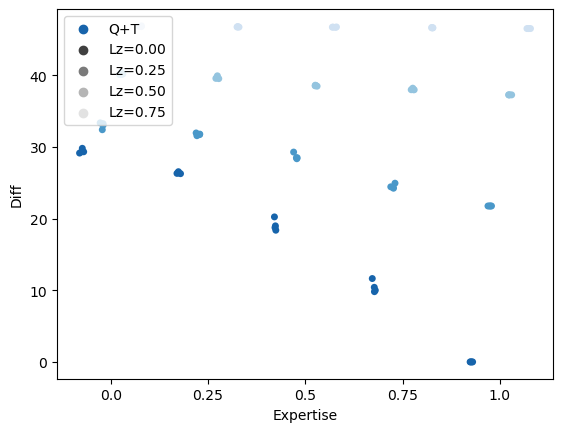

Counter({99: 859, 3: 849, 97: 812, 5: 803, 71: 800, 90: 798, 79: 784, 95: 783, 96: 780, 85: 779, 75: 773, 87: 771, 1: 767, 2: 763, 74: 755, 94: 752, 10: 751, 93: 745, 68: 735, 69: 734, 24: 732, 64: 731, 9: 728, 7: 725, 18: 724, 8: 723, 6: 719, 55: 718, 92: 713, 54: 709, 11: 707, 89: 704, 12: 701, 30: 701, 84: 701, 0: 700, 22: 694, 38: 691, 78: 690, 33: 689, 23: 686, 47: 686, 88: 686, 66: 685, 83: 685, 81: 682, 56: 681, 14: 680, 59: 675, 34: 672, 13: 671, 80: 670, 31: 664, 4: 663, 50: 663, 91: 663, 98: 663, 77: 662, 27: 655, 15: 652, 73: 652, 86: 643, 20: 638, 37: 638, 60: 634, 19: 633, 21: 633, 42: 633, 67: 629, 28: 628, 16: 621, 82: 621, 57: 616, 35: 615, 29: 601, 25: 596, 40: 591, 70: 591, 61: 583, 48: 566, 17: 556, 63: 554, 26: 552, 46: 544, 41: 537, 65: 532, 72: 530, 49: 529, 32: 527, 44: 526, 76: 526, 36: 506, 62: 496, 51: 492, 43: 483, 45: 480, 58: 476, 53: 470, 39: 438, 52: 393})
dict_values([700, 767, 763, 849, 663, 803, 719, 725, 723, 728, 751, 707, 701, 671, 680, 652, 621, 55

In [42]:
# create palette
mechanisms = ['Q+T']
laziness_vec = [0.0, 0.25, 0.5, 0.75]
color_range = np.linspace(0.8, 0.2, len(laziness_vec))
colors=['Blues', 'Greens', 'Reds', 'Purples']
palette = {}
for jj, m in enumerate(mechanisms):
    color = mpl.colormaps[colors[jj]]
    for ii, l in enumerate(laziness_vec):
        key='%s//%0.02f' % (m, l,)
        palette[key] = color(color_range[ii])

ax = sns.stripplot(
    data=dff, x="avg_expertise", y="Diff", hue="Hue",
    dodge=True, zorder=1, legend=False, palette=palette,
)
plt.xlabel('Expertise')
plt.ylabel('Diff')
# plt.legend(title='Mechanism//Laziness')
# create custom legend
for ii, m in enumerate(mechanisms):
    ax.scatter([], [], color=mpl.colormaps[colors[ii]](0.8), label=mechanisms[ii])
for ii, l in enumerate(laziness_vec):
    ax.scatter([], [], color=mpl.colormaps['Greys'](color_range[ii]), label='Lz=%0.02f' % l)
ax.legend(loc='upper left')

#### Notes on Alignment for Q+T
1. Q+T has less alignment than Pairwise.  Even if the expertise is normalized, it is less b/c
   the user must also assign funding amounts to each project.  This introduces an additional source
   of randomness.
2. Even if it is not random (i.e. top ranked project gets top amount and then work down), all badgeholder's views are aggregated and this introduces some noise in the alignment.
3. Interestingly, as badgeholder laziness goes up in the Q+T scheme, the alignment seems to get better. Likely b/c they vote on less projects, so there is less ambiguity in assigning projects closer amounts of funding, causing
4. It really depends on how a Q+T badgeholder assigns funding to the projects after they have ranked them.
5. This means the above plot may not be completely fair in terms of comparison, in the sense that pairwise is comparing alignment directly, where as Q+T is including the scoring aspect.  That being said, that is sort of the mechanism, since in pairwise, we only want rankings and then we create an a-priori mapping to funding amount, so this is sort of an advantage in the sense that it creates a clearer signal.
